In [350]:
from pathlib import Path
from scipy.stats import chi2_contingency, normaltest, mannwhitneyu
import matplotlib.pyplot as plt
import pandas as pd

In [351]:
# Для отображения числе не в экспоненциальном виде, а обрезанными до двух знаков после запятой
pd.options.display.float_format = '{:.2f}'.format

In [352]:
project_dir = Path.cwd().parent
data_path = project_dir / 'data' / 'marketplace.csv'
marketplace = pd.read_csv(data_path)
marketplace.head()

,user_id,platform_num,first_login,reg_dt,browser,first_buy,target,total_buy,total_return
0,user_000000,12,2025-03-22,2024-08-17,browser_00,2025-03-22,0.00,85.33,0.00
1,user_000001,1,2025-05-05,2025-05-15,browser_01,2025-05-20,0.00,21.82,0.00
2,user_000002,5,2025-01-19,2025-01-23,browser_02,2025-02-20,0.30,194.61,485.00
3,user_000003,3,2025-03-15,2023-09-05,browser_02,NaN,0.00,138.78,0.00
4,user_000004,1,2025-05-05,2025-05-14,browser_00,2025-05-11,0.00,16.33,0.00


In [353]:
marketplace.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25335 entries, 0 to 25334
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   user_id       25335 non-null  object 
 1   platform_num  25335 non-null  int64  
 2   first_login   25335 non-null  object 
 3   reg_dt        25331 non-null  object 
 4   browser       25335 non-null  object 
 5   first_buy     24361 non-null  object 
 6   target        25335 non-null  float64
 7   total_buy     25335 non-null  float64
 8   total_return  25335 non-null  float64
dtypes: float64(3), int64(1), object(5)
memory usage: 1.7+ MB


In [354]:
marketplace.describe()

,platform_num,target,total_buy,total_return
count,25335.00,25335.00,25335.00,25335.00
mean,6.47,0.00,898.55,334.08
std,17.02,0.25,6815.55,2882.91
min,1.00,-3.43,0.00,0.00
25%,2.00,0.00,19.36,0.00
50%,3.00,0.00,52.72,0.00
75%,6.00,0.00,203.53,0.00
max,674.00,0.30,490447.99,207893.84


## Количество отрицательных значений **target**

In [355]:
marketplace[marketplace["target"] < 0]["target"].count()

np.int64(353)

In [356]:
marketplace[marketplace["target"] > 0]["target"].count()

np.int64(1966)

In [357]:
marketplace["target"].describe()

count   25335.00
mean        0.00
std         0.25
min        -3.43
25%         0.00
50%         0.00
75%         0.00
max         0.30
Name: target, dtype: float64

<Axes: >

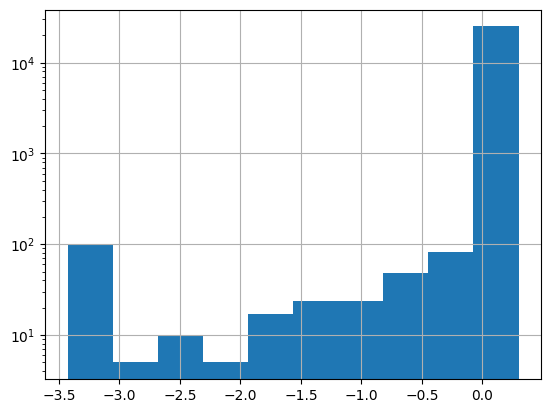

In [358]:
marketplace["target"].hist(log=True)

# Изучение дат

In [359]:
marketplace["first_login"] = pd.to_datetime(marketplace["first_login"])
marketplace["reg_dt"] = pd.to_datetime(marketplace["reg_dt"])
marketplace["first_buy"] = pd.to_datetime(marketplace["first_buy"])
marketplace.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25335 entries, 0 to 25334
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   user_id       25335 non-null  object        
 1   platform_num  25335 non-null  int64         
 2   first_login   25335 non-null  datetime64[ns]
 3   reg_dt        25331 non-null  datetime64[ns]
 4   browser       25335 non-null  object        
 5   first_buy     24361 non-null  datetime64[ns]
 6   target        25335 non-null  float64       
 7   total_buy     25335 non-null  float64       
 8   total_return  25335 non-null  float64       
dtypes: datetime64[ns](3), float64(3), int64(1), object(2)
memory usage: 1.7+ MB


In [360]:
marketplace[
    (marketplace["first_login"] < marketplace["reg_dt"]) | # первый логин раньше регистрации
    (marketplace["first_buy"] < marketplace["first_login"]) | # первая покупка раньше певого логина
    (marketplace["first_buy"] < marketplace["reg_dt"]) # первая покупка раньше регистрации
].info()

<class 'pandas.core.frame.DataFrame'>
Index: 16777 entries, 1 to 25334
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   user_id       16777 non-null  object        
 1   platform_num  16777 non-null  int64         
 2   first_login   16777 non-null  datetime64[ns]
 3   reg_dt        16777 non-null  datetime64[ns]
 4   browser       16777 non-null  object        
 5   first_buy     16640 non-null  datetime64[ns]
 6   target        16777 non-null  float64       
 7   total_buy     16777 non-null  float64       
 8   total_return  16777 non-null  float64       
dtypes: datetime64[ns](3), float64(3), int64(1), object(2)
memory usage: 1.3+ MB


# Добавление новых признаков датасету для анализа
1. **age_days** - количество дней с первой покупки пользователя
2. **age_group** - разбиение пользователей по группам на основе количества дней с первой покупки
3. **only_returns** - флаг, говорящий о том, что у пользователя нет покупок, только возвраты
4. **return_ratio** - отношение возвратов к покупкам

In [361]:
today = marketplace["first_buy"].max()
marketplace["age_days"] = (today - marketplace["first_buy"]).dt.days
marketplace["age_days"].describe()

count   24361.00
mean      135.43
std        86.01
min         0.00
25%        85.00
50%       122.00
75%       165.00
max       717.00
Name: age_days, dtype: float64

In [362]:
bins = [0, 85, 122, 165, 717, float("inf")]
labels = ["new", "young", "mid", "mature", "old"]

marketplace["age_group"] = pd.cut(
    marketplace["age_days"],
    bins=bins,
    labels=labels,
    right=False
)
marketplace["age_group"] = marketplace["age_group"].cat.add_categories("inactive")
marketplace.loc[marketplace["first_buy"].isna(), "age_group"] = "inactive"
marketplace["age_group"].describe()

count     25335
unique        6
top         mid
freq       6247
Name: age_group, dtype: object

In [363]:
marketplace["only_returns"] = (marketplace["total_buy"] == 0) & (marketplace["total_return"] > 0)
marketplace["only_returns"].describe()

count     25335
unique        2
top       False
freq      25183
Name: only_returns, dtype: object

In [364]:
EPS = 1e-9
def calc_return_ratio(row):
    buy = row["total_buy"]
    ret = row["total_return"]
    if ret == 0:
        return 0
    if buy == 0:
        buy = EPS
    return (ret / buy)

marketplace["return_ratio"] = marketplace.apply(calc_return_ratio, axis=1)
marketplace[~marketplace["only_returns"]]["return_ratio"].describe()

count   25183.00
mean        2.38
std       242.13
min         0.00
25%         0.00
50%         0.00
75%         0.00
max     38227.85
Name: return_ratio, dtype: float64

# Анализ пользователей у которых есть только возрвраты

In [365]:
df_with_returns = pd.DataFrame(marketplace[marketplace["only_returns"]])
del df_with_returns["return_ratio"]
df_with_returns.describe()

,platform_num,first_login,reg_dt,first_buy,target,total_buy,total_return,age_days
count,152.00,152,152,151,152.00,152.00,152.00,151.00
mean,4.86,2025-02-09 23:03:09.473684224,2025-01-19 21:18:56.842105344,2025-01-31 17:57:36.953642496,-0.02,0.00,104.23,174.25
min,1.00,2024-10-13 00:00:00,2024-01-07 00:00:00,2024-01-10 00:00:00,-3.43,0.00,21.99,15.00
25%,2.00,2025-01-20 00:00:00,2025-01-10 00:00:00,2025-01-19 00:00:00,0.00,0.00,24.08,136.50
50%,3.00,2025-02-09 00:00:00,2025-02-09 12:00:00,2025-02-14 00:00:00,0.00,0.00,37.01,161.00
75%,5.25,2025-03-07 00:00:00,2025-03-08 12:00:00,2025-03-10 12:00:00,0.00,0.00,59.54,187.00
max,56.00,2025-07-19 00:00:00,2025-07-17 00:00:00,2025-07-10 00:00:00,0.30,0.00,3272.02,562.00
std,6.09,NaN,NaN,NaN,0.28,0.00,347.08,86.75


In [366]:
df_with_returns.info()

<class 'pandas.core.frame.DataFrame'>
Index: 152 entries, 115 to 24672
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   user_id       152 non-null    object        
 1   platform_num  152 non-null    int64         
 2   first_login   152 non-null    datetime64[ns]
 3   reg_dt        152 non-null    datetime64[ns]
 4   browser       152 non-null    object        
 5   first_buy     151 non-null    datetime64[ns]
 6   target        152 non-null    float64       
 7   total_buy     152 non-null    float64       
 8   total_return  152 non-null    float64       
 9   age_days      151 non-null    float64       
 10  age_group     152 non-null    category      
 11  only_returns  152 non-null    bool          
dtypes: bool(1), category(1), datetime64[ns](3), float64(4), int64(1), object(2)
memory usage: 13.6+ KB


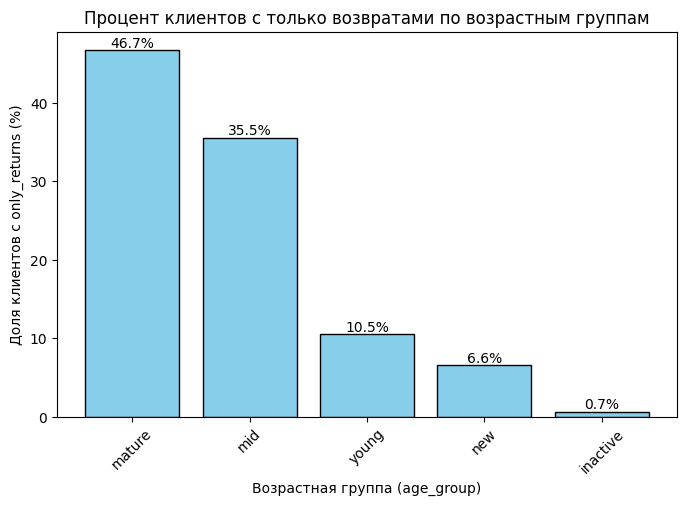

In [367]:
returns_by_age_group = df_with_returns.groupby("age_group", observed=True)[
    "user_id"].count() / df_with_returns["user_id"].count() * 100

returns_by_age_group = returns_by_age_group.sort_values(
    ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(returns_by_age_group.index,
              returns_by_age_group.values, color="skyblue", edgecolor="black")

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height,
            f'{height:.1f}%', ha='center', va='bottom')

ax.set_ylabel("Доля клиентов с only_returns (%)")
ax.set_xlabel("Возрастная группа (age_group)")
ax.set_title("Процент клиентов с только возвратами по возрастным группам")
plt.xticks(rotation=45)
plt.show()

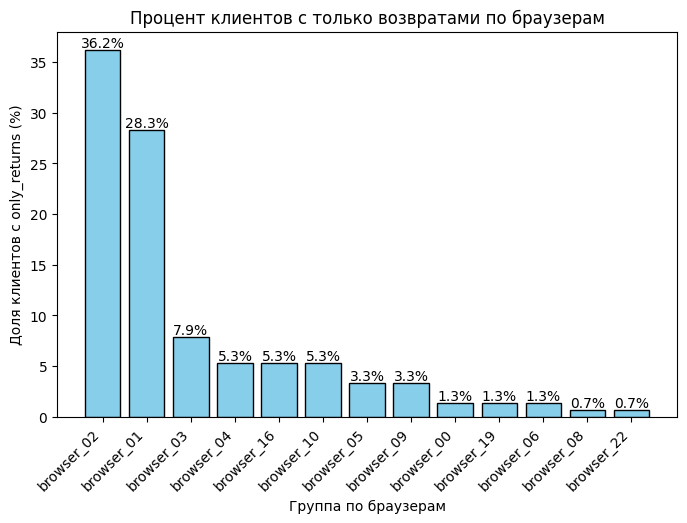

In [368]:
returns_by_browser = df_with_returns.groupby("browser", observed=True)[
    "user_id"].count() / df_with_returns["user_id"].count() * 100

returns_by_browser = returns_by_browser.sort_values(
    ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(returns_by_browser.index,
              returns_by_browser.values, color="skyblue", edgecolor="black")

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height,
            f'{height:.1f}%', ha='center', va='bottom')

ax.set_ylabel("Доля клиентов с only_returns (%)")
ax.set_xlabel("Группа по браузерам")
ax.set_title("Процент клиентов с только возвратами по браузерам")
plt.xticks(rotation=45, ha='right')
plt.show()

## Изучение признака platform_num

In [369]:
marketplace[marketplace["platform_num"] == marketplace["platform_num"].max()]

,user_id,platform_num,first_login,reg_dt,browser,first_buy,target,total_buy,total_return,age_days,age_group,only_returns,return_ratio
1927,user_001925,674,2024-11-12,2024-07-25,browser_03,2024-08-03,0.30,45877.83,24302.00,356.00,mature,False,0.53


In [370]:
marketplace.sort_values("platform_num", ascending=False).head(10)

,user_id,platform_num,first_login,reg_dt,browser,first_buy,target,total_buy,total_return,age_days,age_group,only_returns,return_ratio
1927,user_001925,674,2024-11-12,2024-07-25,browser_03,2024-08-03,0.30,45877.83,24302.00,356.00,mature,False,0.53
14553,user_014550,647,2024-10-02,2024-09-05,browser_03,2024-09-21,-0.00,15754.61,10643.36,307.00,mature,False,0.68
3067,user_003065,542,2024-10-11,2024-07-26,browser_02,2024-09-15,0.10,66582.73,20983.01,313.00,mature,False,0.32
18597,user_018594,540,2024-12-14,2024-12-01,browser_03,2024-11-26,0.30,18992.27,10651.05,241.00,mature,False,0.56
17874,user_017871,475,2024-11-02,2024-10-31,browser_03,2024-12-09,0.22,20179.29,4050.00,228.00,mature,False,0.20
10881,user_010878,399,2025-03-30,2024-01-27,browser_03,2025-03-16,0.30,5364.42,2498.61,131.00,mid,False,0.47
7787,user_007784,391,2024-12-05,2024-12-09,browser_06,2024-12-15,-2.03,3425.46,2120.53,222.00,mature,False,0.62
15114,user_015111,380,2024-10-02,2024-06-17,browser_03,2024-09-24,0.30,15981.50,0.00,304.00,mature,False,0.00
435,user_000433,358,2024-10-02,2024-10-03,browser_03,2024-09-29,0.00,5073.51,3175.00,299.00,mature,False,0.63
12776,user_012773,352,2025-03-22,2022-12-28,browser_03,2025-03-16,0.00,9723.93,9682.00,131.00,mid,False,1.00


Топ-10 по количеству устройств выглядит неестественным.
### Список гипотез:
- Гипотеза А: технический баг:\
Количество устройств считается неправильно
- Гипотеза B: мошеннические аккаунты
- Гипотеза C: коллективные аккаунты

#### Отличительные признаки
Топ-10 по количеству устройств выше 75-го перцентиля по total_buy и total_return (кроме одной строки).

In [371]:
df_with_large_platform_num = pd.DataFrame(
    marketplace[marketplace["platform_num"] > marketplace["platform_num"].quantile(0.9)]
)
df_with_large_platform_num.describe()

,platform_num,first_login,reg_dt,first_buy,target,total_buy,total_return,age_days,return_ratio
count,2440.00,2440,2440,2434,2440.00,2440.00,2440.00,2434.00,2440.00
mean,34.39,2025-01-19 09:26:33.442622976,2024-09-25 15:56:39.344262144,2025-01-09 12:44:22.284305664,0.02,2971.22,1159.02,196.47,127248556.97
min,13.00,2024-09-21 00:00:00,2022-10-14 00:00:00,2023-08-12 00:00:00,-3.43,0.00,0.00,4.00,0.00
25%,15.00,2024-11-14 00:00:00,2024-07-30 00:00:00,2024-11-17 00:00:00,0.00,52.99,0.00,122.00,0.00
50%,21.00,2025-01-29 00:00:00,2024-11-17 00:00:00,2025-02-03 00:00:00,0.00,215.58,0.00,172.00,0.00
75%,34.00,2025-03-22 00:00:00,2025-02-07 00:00:00,2025-03-25 00:00:00,0.00,1209.19,280.00,250.00,0.40
max,674.00,2025-07-19 00:00:00,2025-07-19 00:00:00,2025-07-21 00:00:00,0.30,490447.99,207893.84,713.00,59829575000.00
std,45.58,NaN,NaN,NaN,0.30,14660.81,6224.78,103.43,2224314311.98


# Проверка гипотезы о большом ***platform_num***
Сравним распределение категориального признака ***browser*** между двумя независимыми группами:
1. Пользователи с ***platform_num*** > 90-го перцентиля
2. Все остальные

Используем критерий χ², чтобы оценить насколько сильно отличаются частоты категорий.\
H<sub>0</sub>: Распределение браузеров одинаково в обеих группах\
H<sub>1</sub>: Распределение браузеров отличается\
Уровень значимости α = 0.05

Если принимаем гипотезу H<sub>1</sub> - есть аномальные каналы связи по которым приходят боты.

In [372]:
marketplace["browser"] = marketplace["browser"].astype("category")

threshold = marketplace["platform_num"].quantile(0.9)

df_large = marketplace[marketplace["platform_num"] > threshold]
df_small = marketplace[marketplace["platform_num"] <= threshold]
contingency = pd.crosstab(
    marketplace["browser"],
    marketplace["platform_num"] > threshold
)
chi2, p, dof, expected = chi2_contingency(contingency)
print("Гипотезу 0 принимаем" if p > 0.05 else "Гипотезу 0 отвергаем")
print(f"p-value: {p:.3g}")

Гипотезу 0 отвергаем
p-value: 1.22e-58


***p_value*** < 0.05:
- H<sub>0</sub> отвергается
- распределения браузеров отличаются статистически значимо
- есть браузеры, которые непропорционально часто встречаются в "подозрительной" группе
- возможен фродовый канал трафика

## Анализ остатков
residual ~ N(0,1)\
~95% попадают в [-2;2]

In [373]:
residuals = (contingency - expected) / expected**0.5
suspicious = residuals[True][residuals[True] > 2].sort_values(ascending=False)
display(suspicious)

browser
browser_03   13.28
browser_28    2.91
browser_30    2.91
browser_17    2.59
Name: True, dtype: float64

Браузеры:
* 03
* 28
* 30
* 17

Встречаются чаще у пользователей с большим количеством устройств

# Анализ группы пользователей с "подозрительными" браузерами

In [374]:
suspicious_browsers = ["browser_03", "browser_28", "browser_30", "browser_17"]
df_suspicious = marketplace[marketplace["browser"].isin(suspicious_browsers)]
df_suspicious.describe()

,platform_num,first_login,reg_dt,first_buy,target,total_buy,total_return,age_days,return_ratio
count,5931.00,5931,5930,5722,5931.00,5931.00,5931.00,5722.00,5931.00
mean,9.42,2025-03-19 15:54:54.081942272,2024-12-18 05:45:33.086003200,2025-03-16 13:54:45.424676864,0.01,1421.76,499.17,130.42,133620009.89
min,1.00,2024-09-21 00:00:00,2022-10-11 00:00:00,2023-08-12 00:00:00,-3.43,0.00,0.00,0.00,0.00
25%,2.00,2025-02-17 00:00:00,2024-10-25 06:00:00,2025-02-18 00:00:00,0.00,23.43,0.00,78.00,0.00
50%,4.00,2025-03-25 00:00:00,2025-02-28 00:00:00,2025-03-28 00:00:00,0.00,67.71,0.00,119.00,0.00
75%,8.00,2025-05-02 00:00:00,2025-04-27 00:00:00,2025-05-08 00:00:00,0.00,296.06,0.00,157.00,0.00
max,674.00,2025-07-26 00:00:00,2025-07-26 00:00:00,2025-07-25 00:00:00,0.30,490447.99,207893.84,713.00,257523160000.00
std,26.36,NaN,NaN,NaN,0.23,11072.88,4407.45,86.06,4041527400.48


In [375]:
print(f"Среднее отношение возвратов к покупкам в исходном датасете: {marketplace[~marketplace["only_returns"]]["return_ratio"].mean():.2f}\n"
      f"Среднее отношение возвратов к покупкам в группе с подозрительными браузерами: {df_suspicious[~df_suspicious["only_returns"]]["return_ratio"].mean():.2f}\n"
      f"Доля клиентов, делающих только возвраты в исходном датасете: {marketplace["only_returns"].mean():.2f}\n"
      f"Доля клиентов, делающих только возвраты в группе с подозрительными браузерами: {df_suspicious["only_returns"].mean():.2f}\n"
      )

Среднее отношение возвратов к покупкам в исходном датасете: 2.38
Среднее отношение возвратов к покупкам в группе с подозрительными браузерами: 7.21
Доля клиентов, делающих только возвраты в исходном датасете: 0.01
Доля клиентов, делающих только возвраты в группе с подозрительными браузерами: 0.00



## Рассмотрим изменения среднего **return_ratio** статистически значимы или нет
- Оценим нормальность распределения **return_ratio** для всей выборки и для группы с подозрительными браузерами
- Выберем метод оценки: t-тест для нормального распределения, Mann-Whitney U тест для другого

In [376]:
all_return_ratio = marketplace[~marketplace["only_returns"]]["return_ratio"].dropna()
suspicious_return_ratio = df_suspicious[~df_suspicious["only_returns"]]["return_ratio"].dropna()
print(all_return_ratio.count(), suspicious_return_ratio.count())

25183 5919


Выборки содержат более 5000 экземпляров: используем normaltest для оценки нормальности распределения

In [377]:
stat, p = normaltest(all_return_ratio)
print(f"Normal test p-value для всей выборки: {p:.3g}")

Normal test p-value для всей выборки: 0


In [378]:
stat, p = normaltest(suspicious_return_ratio)
print(f"Normal test p-value для группы подозрительных браузеров: {p:.3g}")

Normal test p-value для группы подозрительных браузеров: 0


**return_ratio** распределён не нормально, выбираем Mann-Whitney U тест\
H<sub>0</sub>: Распределение **return_ratio** в группе подозрительных браузеров такое же, как в общей выборке пользователей\
Выбираем альтернативную гипотезу greater, потому что хотим убедиться, что suspicious_return_ratio статистически значимо выше

In [379]:
stat, p = mannwhitneyu(
    all_return_ratio, 
    suspicious_return_ratio, 
    alternative='greater'
)
print("Гипотезу 0 принимаем" if p > 0.05 else "Гипотезу 0 отвергаем")
print(f"Манна-Уитни U-statistic: {stat:.2f}, p-value: {p:.3g}")

Гипотезу 0 отвергаем
Манна-Уитни U-statistic: 75487553.50, p-value: 0.0147


Уровень значимости α = 0.05\
p-value < 0.05 следовательно нулевую гипотезу отвергаем\
В группе пользователей с подозрительными браузерами доля возвратов в процентах статистически выше, чем во всей выборке

# Распределение **return_ratio** по возрастным группам

In [380]:
marketplace[~marketplace["only_returns"]].groupby("age_group", observed=True)["return_ratio"].mean()

age_group
new        7.07
young      0.85
mid        0.70
mature     1.28
old        0.82
inactive   0.52
Name: return_ratio, dtype: float64

In [381]:
marketplace[~marketplace["only_returns"]][marketplace["age_group"] == "new"]["return_ratio"].describe()

C:\Users\Михаил\AppData\Local\Temp\ipykernel_8852\667815032.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  marketplace[~marketplace["only_returns"]][marketplace["age_group"] == "new"]["return_ratio"].describe()


count    5995.00
mean        7.07
std       494.15
min         0.00
25%         0.00
50%         0.00
75%         0.00
max     38227.85
Name: return_ratio, dtype: float64

# TO DO LIST:
* Оценить как долго кастомер у нас уже покупает (на основе этого можно построить признаки return_per_date, buy_per_date)
* Корреляция браузеров с возвратами доказана по Манна-Уитни тесту, далее необходимо оценить является ли браузер сам по себе причиной повышенных возвратов